# Sensitivity analysis II - the full grid (H1-H5 x U1-U3)

- **Attribution heuristic (D2):** H1 tag-only, H2 address-only, H3 union
  (tag-preferred), H4 intersection (both must agree), H5 union (address-preferred).
- **Unknown treatment (D3):** U1 single entity, U2 exclude, U3 assign to largest.

**15 attribution scenarios**, each a full metric time series. The band they
span is your total sensitivity to attribution choice. Then the headline question:
do the 2017 trough and post-2019 re-concentration survive *how you identify pools*,
not just what you do with the leftovers?

Runs on `attributed_full.parquet`

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from stage3_metrics.decentralisation import all_metrics
except ModuleNotFoundError:
    import sys
    sys.path.insert(0, os.path.abspath("../src"))
    from stage3_metrics.decentralisation import all_metrics

full = pd.read_parquet("../data/derived/attributed_full.parquet")
print(f"loaded {len(full):,} blocks with tag_pool + addr_pool")

loaded 954,375 blocks with tag_pool + addr_pool


## The five heuristics, and the coverage each implies

Each heuristic turns `tag_pool` + `addr_pool` into one final label. They differ
mainly in how much of the chain they're willing to attribute, which matters,
because a heuristic that attributes little (H4) computes its metric over a small,
biased subset (only the well-known pools both methods agree on).

In [2]:
def heuristic_pool(tag, addr, H):
    has_tag, has_addr = tag.notna(), addr.notna()
    either = has_tag | has_addr
    if H == "H1":                                   # tag only
        pool = tag.where(has_tag, "unknown")
    elif H == "H2":                                 # address only
        pool = addr.where(has_addr, "unknown")
    elif H == "H3":                                 # union, tag-preferred
        pool = tag.where(has_tag, addr).where(either, "unknown")
    elif H == "H5":                                 # union, address-preferred (conflict resolution)
        pool = addr.where(has_addr, tag).where(either, "unknown")
    elif H == "H4":                                 # intersection: only where both agree
        agree = has_tag & has_addr & (tag == addr)
        pool = tag.where(agree, "unknown")
    return pool.astype(object)

HEURISTICS = ["H1", "H2", "H3", "H4", "H5"]
labels = {"H1": "tag only", "H2": "address only", "H3": "union (tag-pref)",
          "H4": "intersection", "H5": "union (addr-pref)"}
for H in HEURISTICS:
    p = heuristic_pool(full["tag_pool"], full["addr_pool"], H)
    print(f"  {H} {labels[H]:18}: {(p != 'unknown').mean():5.1%} attributed")

  H1 tag only          : 70.0% attributed


  H2 address only      : 35.6% attributed


  H3 union (tag-pref)  : 76.2% attributed


  H4 intersection      : 29.2% attributed


  H5 union (addr-pref) : 76.2% attributed


## Run the full sweep

15 scenarios x ~190 months.

In [3]:
def apply_unknown_treatment(counts, treatment):
    counts = dict(counts)
    unknown = counts.pop("unknown", 0)
    if treatment == "U1":
        if unknown > 0:
            counts["unknown"] = unknown
    elif treatment == "U2":
        pass
    elif treatment == "U3":
        if counts and unknown > 0:
            counts[max(counts, key=counts.get)] += unknown
        elif unknown > 0:
            counts["unknown"] = unknown
    return counts

def sweep_full(df, heuristics=HEURISTICS, treatments=("U1", "U2", "U3"), period="M"):
    base = df.copy()
    base["window"] = (pd.to_datetime(base["timestamp"]).dt.tz_localize(None)
                      .dt.to_period(period).dt.to_timestamp())
    rows = []
    for H in heuristics:
        base["_pool"] = heuristic_pool(base["tag_pool"], base["addr_pool"], H)
        for window, g in base.groupby("window"):
            counts0 = g["_pool"].value_counts().to_dict()
            for U in treatments:
                counts = apply_unknown_treatment(counts0, U)
                for name, val in all_metrics(counts).items():
                    rows.append({"window": window, "heuristic": H, "treatment": U,
                                 "metric": name, "value": val})
    return pd.DataFrame(rows)

grid = sweep_full(full)
grid.to_parquet("../data/derived/sensitivity_full.parquet")
print(f"{len(grid):,} rows | {grid['heuristic'].nunique()} heuristics x "
      f"{grid['treatment'].nunique()} treatments x {grid['metric'].nunique()} metrics x "
      f"{grid['window'].nunique()} months")

18,900 rows | 5 heuristics x 3 treatments x 6 metrics x 210 months


## The total sensitivity envelope

Per metric: the grey band is the full spread across **all 15 scenarios**; the red
line is your original H1/U2 baseline. Where the baseline sits inside a thin band,
your conclusion is robust to attribution choice. Where the band is fat, it isn't.

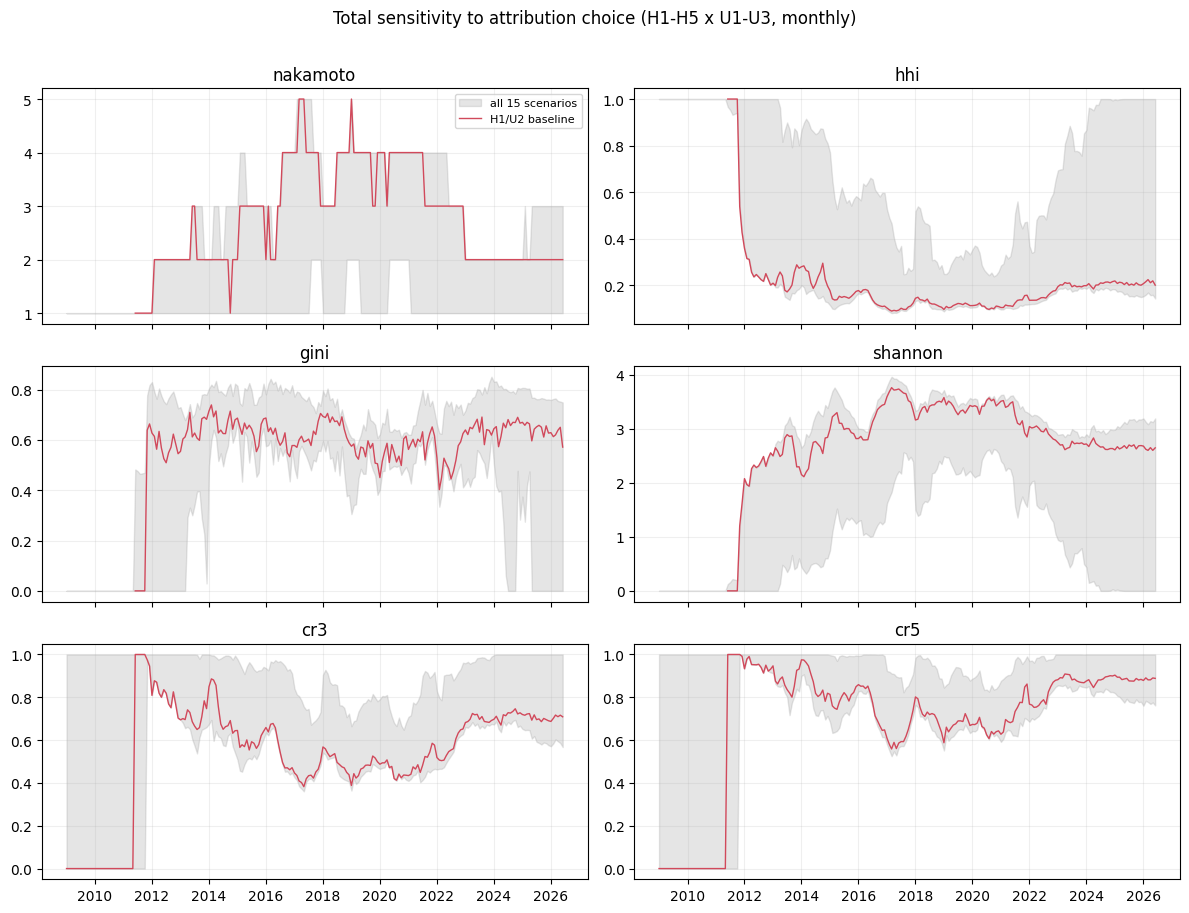

In [4]:
metrics = ["nakamoto", "hhi", "gini", "shannon", "cr3", "cr5"]
fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
for ax, m in zip(axes.ravel(), metrics):
    sub = grid[grid["metric"] == m]
    env = sub.groupby("window")["value"].agg(["min", "max"])
    base = sub[(sub["heuristic"] == "H1") & (sub["treatment"] == "U2")].set_index("window")["value"]
    ax.fill_between(env.index, env["min"], env["max"], color="grey", alpha=0.2, label="all 15 scenarios")
    ax.plot(base.index, base.values, color="#d1495b", lw=1, label="H1/U2 baseline")
    ax.set_title(m)
    ax.grid(alpha=0.2)
axes.ravel()[0].legend(fontsize=8)
fig.suptitle("Total sensitivity to attribution choice (H1-H5 x U1-U3, monthly)", y=1.01)
fig.tight_layout()
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/sensitivity_full_envelope.png", dpi=120, bbox_inches="tight")
plt.show()

## How the heuristics themselves differ (unknowns excluded, U2)

Isolating the heuristic axis: same unknown treatment (U2), five heuristics. Watch
H1/H3/H5 (the high-coverage choices) cluster together while H2 (address-only) and
H4 (intersection) wander off because they attribute far less and so measure a
different, smaller slice of the chain.

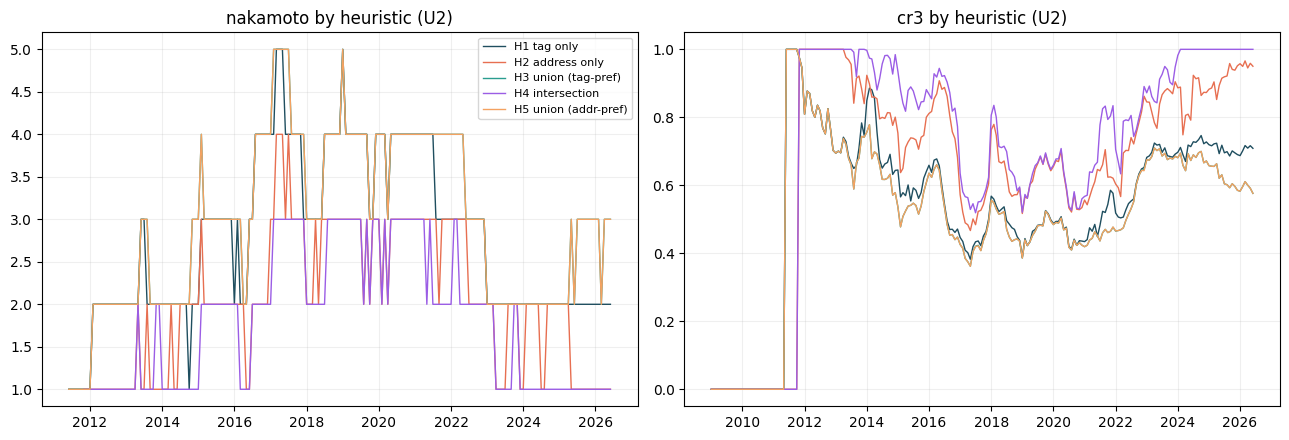

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = {"H1": "#1f4e5f", "H2": "#e76f51", "H3": "#2a9d8f", "H4": "#9b5de5", "H5": "#f4a261"}
for ax, m in zip(axes, ["nakamoto", "cr3"]):
    for H in HEURISTICS:
        s = grid[(grid["metric"] == m) & (grid["heuristic"] == H) &
                 (grid["treatment"] == "U2")].set_index("window")["value"]
        ax.plot(s.index, s.values, color=colors[H], lw=1, label=f"{H} {labels[H]}")
    ax.set_title(f"{m} by heuristic (U2)")
    ax.grid(alpha=0.2)
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig("../figures/sensitivity_by_heuristic.png", dpi=120, bbox_inches="tight")
plt.show()

## Which axis drives the uncertainty?

For the high-coverage era (2018+), the band width from: the full grid; varying only
the **heuristic** (at U2); varying only the **unknown treatment** (at H1). Comparing
the last two tells you whether *how you combine methods* or *what you do with
unknowns* is the bigger source of uncertainty.

In [6]:
def axis_bands(metric, year_from=2018):
    sub = grid[grid["metric"] == metric].copy()
    sub = sub[pd.to_datetime(sub["window"]).dt.year >= year_from]
    full_b = sub.groupby("window")["value"].agg(lambda v: v.max() - v.min()).mean()
    heur_b = (sub[sub["treatment"] == "U2"].groupby("window")["value"]
              .agg(lambda v: v.max() - v.min()).mean())
    unk_b = (sub[sub["heuristic"] == "H1"].groupby("window")["value"]
             .agg(lambda v: v.max() - v.min()).mean())
    return full_b, heur_b, unk_b

print(f"{'metric':9} {'full grid':>10} {'heuristic axis':>15} {'unknown axis':>13}   (mean band, 2018+)")
for m in metrics:
    f, h, u = axis_bands(m)
    print(f"{m:9} {f:10.3f} {h:15.3f} {u:13.3f}")

metric     full grid  heuristic axis  unknown axis   (mean band, 2018+)
nakamoto       2.049           1.196         0.461
hhi            0.469           0.272         0.037
gini           0.342           0.241         0.040
shannon        1.993           1.375         0.233
cr3            0.344           0.250         0.068
cr5            0.229           0.187         0.053
